# Two-lane Nagel-Schreckenberg with CWS Lane-Changing

This notebook extends the single-lane NaSch model in
[`nagel_schreckenberg.ipynb`](nagel_schreckenberg.ipynb) to two lanes, using the
**Chowdhury-Wolf-Schreckenberg (CWS)** symmetric lane-change rule.

Following the project's self-contained-notebook convention (see `CLAUDE.md`), the single-lane `TrafficCA`, `TrafficCAWithLights`, `TrafficCA_Periodic`, and `fundamental_diagram` are copied here verbatim so the notebook runs standalone. The two-lane classes build on top of them.

## Contents

1. **Imports & Parameters** — global constants
2. **Single-lane baseline** — `TrafficCA`, `TrafficCAWithLights`, `TrafficCA_Periodic`, `fundamental_diagram`
3. **Two-lane model** — `TwoLaneNaSch` class (state, CWS lane-change, per-lane longitudinal update, periodic + open boundaries)
4. **Two-lane with lights** — `TwoLaneNaSchWithLights` reusing the single-lane `TrafficCAWithLights` as a schedule oracle
5. **Regression check** — two-lane with `n_lanes=1, p_chg=0` must reproduce the single-lane fundamental diagram exactly
6. **Sanity checks** — `n_lanes=3` rejection, `p_chg=0` produces zero lane changes, light timing agrees with the single-lane oracle
7. **Effect of lane-changing** — two-lane fundamental diagrams for a range of `p_chg` values

## 1. Imports & Parameters

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

np.random.seed(42)

# ── Road parameters ──────────────────────────────────────────────────────────
L         = 500    # Road length (number of cells per lane)
V_MAX     = 5      # Default maximum velocity (cells per timestep)
P_RAND    = 0.3    # Dawdling/randomisation probability

# ── Simulation parameters ────────────────────────────────────────────────────
T_WARMUP  = 500    # Timesteps discarded before measurement
T_MEASURE = 1000   # Timesteps used for averaging

# ── Two-lane parameters ──────────────────────────────────────────────────────
N_LANES   = 2      # Number of lanes
P_CHG     = 1.0    # Lane-change probability when all four CWS conditions hold

print(f"Road: {N_LANES} lanes x {L} cells | v_max: {V_MAX} | p_rand: {P_RAND} | p_chg: {P_CHG}")
print(f"Warmup: {T_WARMUP} steps | Measurement: {T_MEASURE} steps")

Failed to read module file 'c:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._

Road: 2 lanes x 500 cells | v_max: 5 | p_rand: 0.3 | p_chg: 1.0
Warmup: 500 steps | Measurement: 1000 steps


In [13]:
from nasch import TrafficCA, TrafficCAWithLights, \
    TrafficCA_Periodic, fundamental_diagram
from nasch_two_lane import TwoLaneNaSch, \
    TwoLaneNaSchWithLights, two_lane_fundamental_diagram


## 5. Regression check: two-lane (n_lanes=1, p_chg=0) ≡ single-lane

This is the **non-negotiable correctness check**. With a single lane and lane-changing disabled, the two-lane code has to reproduce the single-lane fundamental diagram — otherwise the update rule is subtly wrong and nothing downstream can be trusted.

Both curves are generated with `np.random.seed(42)` and identical parameters, so the RNG draw sequences match exactly and we expect a **bit-identical** result (max |diff| = 0). A looser Monte Carlo tolerance is kept as a fall-back warning.

In [14]:
V_MAX_TEST = 5
L_TEST     = 200
P_RAND_TEST = 0.3
N_DENS     = 20
T_W        = 300
T_M        = 500
TOL        = 0.02   # ≈ 4× Monte-Carlo sigma at these params

np.random.seed(42)
rho_ref, J_ref = fundamental_diagram(v_max=V_MAX_TEST, L=L_TEST, p_rand=P_RAND_TEST,
                                     n_densities=N_DENS,
                                     T_warmup=T_W, T_measure=T_M)

np.random.seed(42)
rho_two, J_two = two_lane_fundamental_diagram(v_max=V_MAX_TEST, L=L_TEST,
                                              p_rand=P_RAND_TEST, n_lanes=1,
                                              p_chg=0.0, n_densities=N_DENS,
                                              T_warmup=T_W, T_measure=T_M)

assert np.allclose(rho_ref, rho_two), 'density grid mismatch'

diffs = J_two - J_ref
max_diff = float(np.max(np.abs(diffs)))

print('  rho     J_single   J_two       diff')
for r, j1, j2, d in zip(rho_ref, J_ref, J_two, diffs):
    print(f'  {r:5.3f}   {j1:.6f}   {j2:.6f}   {d:+.2e}')

print(f'\nmax |J_two - J_single| = {max_diff:.3e}   tol = {TOL:.2e}')
if max_diff < 1e-12:
    print('PASS (bit-identical — RNG traces match)')
elif max_diff < TOL:
    print('PASS (within Monte-Carlo tolerance)')
else:
    raise AssertionError('REGRESSION FAILED: two-lane(n_lanes=1, p_chg=0) '
                         'does not reproduce single-lane FD')

  rho     J_single   J_two       diff
  0.010   0.046930   0.046930   +0.00e+00
  0.062   0.280570   0.280570   +0.00e+00
  0.113   0.495960   0.495960   +0.00e+00
  0.165   0.458250   0.458250   +0.00e+00
  0.216   0.431110   0.431110   +0.00e+00
  0.268   0.418220   0.418220   +0.00e+00
  0.319   0.388960   0.388960   +0.00e+00
  0.371   0.362530   0.362530   +0.00e+00
  0.423   0.337080   0.337080   +0.00e+00
  0.474   0.304310   0.304310   +0.00e+00
  0.526   0.284300   0.284300   +0.00e+00
  0.577   0.259090   0.259090   +0.00e+00
  0.629   0.231710   0.231710   +0.00e+00
  0.681   0.198480   0.198480   +0.00e+00
  0.732   0.170850   0.170850   +0.00e+00
  0.784   0.143410   0.143410   +0.00e+00
  0.835   0.109250   0.109250   +0.00e+00
  0.887   0.076610   0.076610   +0.00e+00
  0.938   0.044190   0.044190   +0.00e+00
  0.990   0.006910   0.006910   +0.00e+00

max |J_two - J_single| = 0.000e+00   tol = 2.00e-02
PASS (bit-identical — RNG traces match)


### 5.1 Visual overlay

If the regression passes, the two curves are on top of each other — plotting both as a sanity visual.

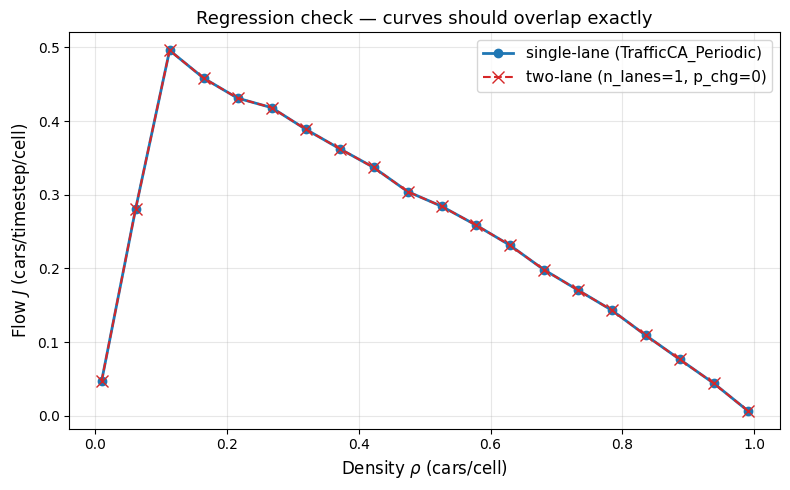

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rho_ref, J_ref, 'o-', color='C0', label='single-lane (TrafficCA_Periodic)',
        linewidth=2, markersize=6)
ax.plot(rho_two, J_two, 'x--', color='C3',
        label='two-lane (n_lanes=1, p_chg=0)', linewidth=1.5, markersize=8)
ax.set_xlabel(r'Density $\rho$ (cars/cell)', fontsize=12)
ax.set_ylabel(r'Flow $J$ (cars/timestep/cell)', fontsize=12)
ax.set_title('Regression check — curves should overlap exactly', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sanity checks

* `n_lanes=3` must raise (CWS is only implemented for two lanes).
* `p_chg=0` must produce zero lane-change events — car IDs stay in their original lanes.
* Two-lane `_red_light_positions(t)` must match single-lane `TrafficCAWithLights._red_light_positions(t)` at every step (confirms the oracle-delegation wiring).


In [16]:
# (a) n_lanes > 2 rejected
try:
    TwoLaneNaSch(L=10, n_lanes=3, n_cars=2)
except ValueError as e:
    print(f'OK — n_lanes=3 raised ValueError: {e}')
else:
    raise AssertionError('n_lanes=3 should have raised')

# (b) p_chg=0 → no lane changes
np.random.seed(42)
sim_nc = TwoLaneNaSch(L=200, n_lanes=2, v_max=5, p_rand=0.3, p_chg=0.0,
                     boundary='periodic', n_cars=80)
ids0_before = set(int(x) for x in sim_nc.car_ids[0][sim_nc.car_ids[0] >= 0])
ids1_before = set(int(x) for x in sim_nc.car_ids[1][sim_nc.car_ids[1] >= 0])
for _ in range(200):
    sim_nc.step()
ids0_after = set(int(x) for x in sim_nc.car_ids[0][sim_nc.car_ids[0] >= 0])
ids1_after = set(int(x) for x in sim_nc.car_ids[1][sim_nc.car_ids[1] >= 0])
assert ids0_after == ids0_before and ids1_after == ids1_before
print(f'OK — p_chg=0: zero lane changes in 200 steps '
      f'({len(ids0_before)} cars in lane 0, {len(ids1_before)} in lane 1)')

# (c) Light oracle delegation — two-lane red columns match single-lane ones
ref = TrafficCAWithLights(L=100, N=3, T_cycle=40, T_green=15, offset=True)
two = TwoLaneNaSchWithLights(L=100, n_lanes=2, N=3, T_cycle=40, T_green=15,
                             offset=True, boundary='open', p_in=0.3)
mismatches = 0
for t in range(500):
    ref.time = t
    two.time = t
    r1 = np.sort(np.asarray(ref._red_light_positions(), dtype=int))
    r2 = np.sort(np.asarray(two._red_light_positions(), dtype=int))
    if not (len(r1) == len(r2) and np.array_equal(r1, r2)):
        mismatches += 1
assert mismatches == 0
print(f'OK — light oracle delegation: 0 mismatches across 500 steps')

OK — n_lanes=3 raised ValueError: n_lanes must be 1 or 2; CWS lane-change is only defined for two lanes.
OK — p_chg=0: zero lane changes in 200 steps (44 cars in lane 0, 36 in lane 1)
OK — light oracle delegation: 0 mismatches across 500 steps


## 7. Effect of lane-changing

With two lanes and `p_chg > 0`, cars can rearrange themselves to exploit gaps in whichever lane is less congested. The fundamental diagram shifts slightly upward near the critical density — fewer cars get stuck behind slower cars in their own lane.

At `p_chg = 0` the two lanes are completely independent (identical to two copies of the single-lane model). At `p_chg = 1` every car that satisfies the CWS conditions switches — maximum mixing.

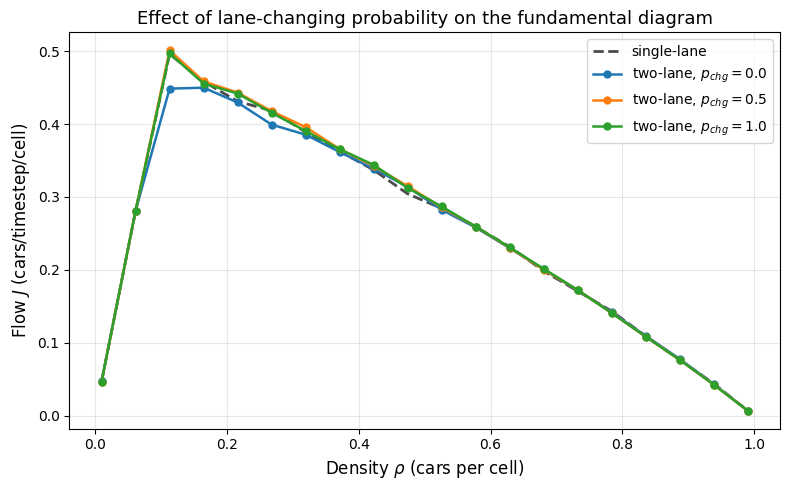

Flow per cell vs single-lane:
  at p_chg=0.0 the two lanes are independent — curve overlaps single-lane.
  at p_chg>0 the peak lifts slightly — lane-switching mitigates local jams.


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

# Single-lane baseline for comparison
np.random.seed(42)
rho1, J1 = fundamental_diagram(v_max=5, L=200, p_rand=0.3,
                               n_densities=20, T_warmup=300, T_measure=500)
ax.plot(rho1, J1, 'k--', linewidth=2, label='single-lane', alpha=0.7)

for p_chg_val, color in zip([0.0, 0.5, 1.0], ['C0', 'C1', 'C2']):
    np.random.seed(42)
    rho2, J2 = two_lane_fundamental_diagram(
        v_max=5, L=200, p_rand=0.3, n_lanes=2, p_chg=p_chg_val,
        n_densities=20, T_warmup=300, T_measure=500,
    )
    ax.plot(rho2, J2, 'o-', color=color, linewidth=1.8, markersize=5,
            label=f'two-lane, $p_{{chg}}={p_chg_val}$')

ax.set_xlabel(r'Density $\rho$ (cars per cell)', fontsize=12)
ax.set_ylabel(r'Flow $J$ (cars/timestep/cell)', fontsize=12)
ax.set_title('Effect of lane-changing probability on the fundamental diagram',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Flow per cell vs single-lane:')
print('  at p_chg=0.0 the two lanes are independent — curve overlaps single-lane.')
print('  at p_chg>0 the peak lifts slightly — lane-switching mitigates local jams.')